# Predicting Wine Price from Expanded Text with ModernBERT

`description` に `points`, 産地、品種、ワイナリーなどの構造化変数をラベル付きテキストとして連結し、$\log(\mathrm{price})$ を予測する回帰モデルです。[`answerdotai/ModernBERT-base`](https://huggingface.co/answerdotai/ModernBERT-base) をfine-tuningします。

### 実行コードの説明

ファイル操作、データ処理、可視化、GPU処理、Hugging Face Dataset、評価指標、ModernBERTのfine-tuningに必要なライブラリを読み込む。`AutoTokenizer` は拡張テキストをトークン列へ変換し、`AutoModelForSequenceClassification` は回帰ヘッド付きモデルとして使用する。乱数シードを42に固定して再現性を確保する。


In [10]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U "transformers>=4.48.0" datasets accelerate scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込み、重複除外、入力テキスト作成

同じレビュー本文が訓練データと評価データに分かれないよう、`description` が重複する行を除外します。構造化変数の欠損は `Unknown` として入力テキストへ明示します。

### 実行コードの説明

レビュー本文、価格、評価点、国、銘柄名、産地、品種、ワイナリーをCSVから読み込む。本文と正の価格がある行を残し、同じ本文を持つ重複レビューを除外する。欠損や空文字を `Unknown` に統一する関数と、各変数の意味を表す英文ラベルを付けて1つの文章へ連結する `build_model_text` を定義する。各行へ適用して `text` を作り、価格の自然対数を回帰ラベルとする。


In [11]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

metadata_columns = [
    "points",
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
read_columns = ["description", "price"] + metadata_columns

df = pd.read_csv(csv_path, usecols=read_columns)
rows_before = len(df)
model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        read_columns,
    ]
    .drop_duplicates(subset=["description"])
    .reset_index(drop=True)
)


def format_metadata_value(value):
    if pd.isna(value) or str(value).strip() == "":
        return "Unknown"
    if isinstance(value, (float, np.floating)) and value.is_integer():
        return str(int(value))
    return str(value).strip()


def build_model_text(
    description,
    points=None,
    country=None,
    designation=None,
    province=None,
    region_1=None,
    region_2=None,
    variety=None,
    winery=None,
):
    fields = [
        f"The number of points WineEnthusiast rated the wine on a scale of 1-100: {format_metadata_value(points)}.",
        f"The country that the wine is from: {format_metadata_value(country)}.",
        f"The vineyard within the winery where the grapes that made the wine are from: {format_metadata_value(designation)}.",
        f"The province or state that the wine is from: {format_metadata_value(province)}.",
        f"The wine growing area in a province or state: {format_metadata_value(region_1)}.",
        f"Sometimes there are more specific regions specified within a wine growing area: {format_metadata_value(region_2)}.",
        f"The type of grapes used to make the wine: {format_metadata_value(variety)}.",
        f"The winery that made the wine: {format_metadata_value(winery)}.",
        f"Review: {format_metadata_value(description)}",
    ]
    return " ".join(fields)


model_data["text"] = model_data.apply(
    lambda row: build_model_text(
        description=row["description"],
        points=row["points"],
        country=row["country"],
        designation=row["designation"],
        province=row["province"],
        region_1=row["region_1"],
        region_2=row["region_2"],
        variety=row["variety"],
        winery=row["winery"],
    ),
    axis=1,
)
model_data["label"] = np.log(model_data["price"]).astype("float32")

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Rows used after filtering and deduplication: {len(model_data):,}")
display(model_data[["description", "text", "price", "label"]].head())
display(model_data["label"].describe().rename("log_price").to_frame())

Loaded: /content/data/winemag-data-130k-v2.csv
Original rows: 129,971
Rows used after filtering and deduplication: 111,567


,description,text,price,label
0,"This is ripe and fruity, a wine that is smooth...",The number of points WineEnthusiast rated the ...,15.0,2.708050
1,"Tart and snappy, the flavors of lime flesh and...",The number of points WineEnthusiast rated the ...,14.0,2.639057
2,"Pineapple rind, lemon pith and orange blossom ...",The number of points WineEnthusiast rated the ...,13.0,2.564949
3,"Much like the regular bottling from 2012, this...",The number of points WineEnthusiast rated the ...,65.0,4.174387
4,Blackberry and raspberry aromas show a typical...,The number of points WineEnthusiast rated the ...,15.0,2.708050


,log_price
count,111567.000000
mean,3.316882
std,0.659377
min,1.386294
25%,2.833213
50%,3.218876
75%,3.737670
max,8.101678


### 元のレビュー本文と拡張テキストの文字数

構造化変数を追加したことで入力長がどの程度増えるか確認します。

### 実行コードの説明

元の `description` と、構造化変数を文章化して追加した `text` の文字数をそれぞれ計算する。平均、四分位点、90・95・99パーセンタイル、最大値を比較し、両方の分布を同じ密度グラフに重ねる。入力が長くなった程度を確認し、後続の最大トークン数で切り捨てが起きそうか判断する参考にする。


,count,mean,std,min,50%,75%,90%,95%,99%,max
description_length,111567.0,244.477328,67.187402,20.0,239.0,285.0,331.0,362.0,431.0,829.0
expanded_text_length,111567.0,770.605663,69.230580,549.0,765.0,812.0,860.0,892.0,961.0,1351.0


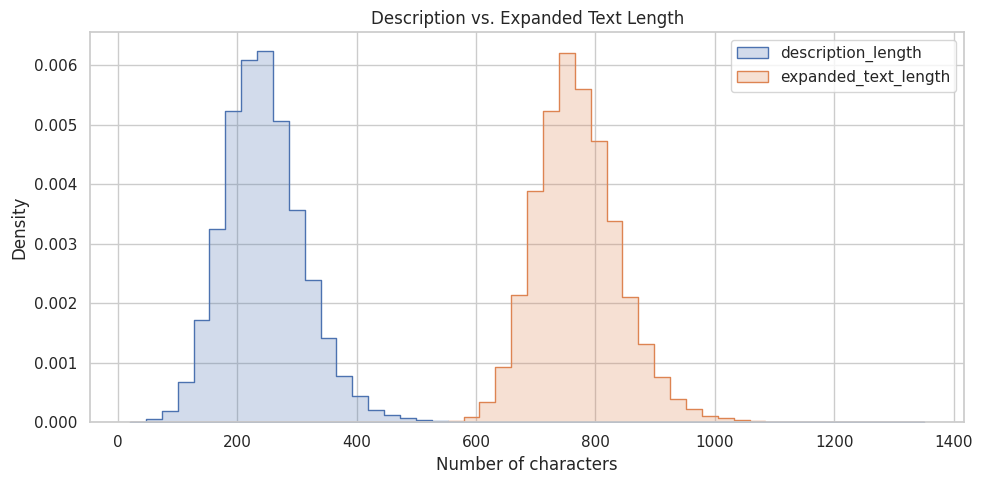

In [12]:
text_lengths = pd.DataFrame({
    "description_length": model_data["description"].str.len(),
    "expanded_text_length": model_data["text"].str.len(),
})
display(
    text_lengths.describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ).T
)

plt.figure(figsize=(10, 5))
sns.histplot(
    text_lengths,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Description vs. Expanded Text Length")
plt.xlabel("Number of characters")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## 2. ModernBERT の準備とデータ分割

80%を訓練、10%を検証、10%を最終テストに使います。`MAX_LENGTH` は文字数ではなくトークン数です。拡張テキストが切り詰められる場合は、GPUメモリを確認しながら増やしてください。

### 実行コードの説明

`answerdotai/ModernBERT-base` のtokenizerと、1つの連続値を出力する回帰モデルを読み込む。必要なら `MAX_ROWS` でデータを固定乱数抽出し、拡張テキストとlog価格をHugging Face Datasetへ変換する。その後、80%の訓練、10%の検証、10%のテストへ分割し、各部分の件数を表示する。


In [13]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 256
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

dataset = Dataset.from_pandas(
    model_data[["text", "label"]], preserve_index=False
)
train_holdout = dataset.train_test_split(test_size=0.2, seed=SEED)
valid_test = train_holdout["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(dataset)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
})


## 3. Tokenization

### 実行コードの説明

拡張テキストをModernBERT用のtoken IDとattention maskへ変換する。`MAX_LENGTH=256` は文字数ではなく最大トークン数であり、長い入力の末尾は切り詰められる。メタデータをレビュー本文より先に配置しているため、切り詰め時にも構造化変数は残りやすい。処理後は元の文字列列を削除する。


In [14]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset

Map:   0%|          | 0/89253 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
})

## 4. 評価指標

学習時の損失とRMSE・MAE・$R^2$ は log価格で計算します。参考として、ドル価格に戻したMAEも計算します。

### 実行コードの説明

`Trainer` が検証・評価時に使用する指標関数を定義する。モデル予測と正解ラベルを1次元へ整形し、log価格でRMSE、MAE、$R^2$ を計算する。さらに指数変換してドル価格へ戻したMAEも計算し、対数尺度と実価格尺度の両方で誤差を確認できるようにする。


In [15]:
def compute_metrics(eval_prediction):
    predictions = np.asarray(eval_prediction.predictions).reshape(-1)
    labels = np.asarray(eval_prediction.label_ids).reshape(-1)
    return {
        "rmse": mean_squared_error(labels, predictions) ** 0.5,
        "mae": mean_absolute_error(labels, predictions),
        "r2": r2_score(labels, predictions),
        "price_mae_usd": mean_absolute_error(
            np.exp(labels), np.exp(predictions)
        ),
    }

## 5. Fine-tuning

GPUが利用可能な場合は mixed precision (`fp16`) を有効にします。検証RMSEが改善しない状態が2回続いた場合は学習を停止します。

### 実行コードの説明

学習率、batch size、最大10 epoch、正則化、warmup、評価・保存頻度を指定する。勾配を2 step蓄積し、GPUがあればfp16を利用する。各epochの検証RMSEを監視し、2回連続で改善しなければearly stoppingする。学習終了後は検証RMSEが最良だった重みを復元する。


In [ ]:
training_args = TrainingArguments(
    output_dir="./wine-review-modernbert-expanded",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.308493,0.160447,0.400559,0.297381,0.641379,11.978136
2,0.207834,0.113611,0.337062,0.246762,0.746065,10.501533
3,0.152269,0.095632,0.309244,0.232667,0.786250,9.895285
4,0.101379,0.090672,0.301117,0.222040,0.797337,9.391089


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 6. テストデータでの最終評価

### 実行コードの説明

学習とモデル選択に使っていないテストDatasetを最良モデルで評価する。`metric_key_prefix="test"` により各指標へ `test_` を付け、loss、RMSE、MAE、$R^2$、ドル価格MAEを表形式で表示する。これが未知データに対する最終性能となる。


In [ ]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)
display(pd.Series(test_metrics, name="value").to_frame())

### 予測値と残差を可視化するコード

テストデータ全件の予測を取得し、実際のlog価格、予測log価格、残差を作成する。左図では45度線との距離、右図では「実際値 − 予測値」の分布を確認する。残差の中心が0からずれていれば系統的な偏り、長い裾があれば一部の大きな予測誤差が示唆される。


In [ ]:
test_output = trainer.predict(tokenized_dataset["test"])
actual_log_price = np.asarray(test_output.label_ids).reshape(-1)
predicted_log_price = np.asarray(test_output.predictions).reshape(-1)
residuals = actual_log_price - predicted_log_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    x=actual_log_price,
    y=predicted_log_price,
    alpha=0.25,
    s=20,
    ax=axes[0],
)
limits = [
    min(actual_log_price.min(), predicted_log_price.min()),
    max(actual_log_price.max(), predicted_log_price.max()),
]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 新しいレビューと構造化変数から価格を予測

### 実行コードの説明

新しいレビュー本文と構造化変数を学習時と同じ `build_model_text` で1つの文章へ変換し、tokenizeして学習済みモデルへ入力する関数を定義する。評価モードと勾配無効化で推論し、実際にモデルへ渡した文章、予測log価格、指数変換したドル価格を返す。最後に入力例を使って推論形式を示す。


In [ ]:
def predict_price(
    description,
    *,
    points=None,
    country=None,
    designation=None,
    province=None,
    region_1=None,
    region_2=None,
    variety=None,
    winery=None,
):
    text = build_model_text(
        description=description,
        points=points,
        country=country,
        designation=designation,
        province=province,
        region_1=region_1,
        region_2=region_2,
        variety=variety,
        winery=winery,
    )
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)
    model.eval()
    with torch.no_grad():
        predicted_log_price = model(**inputs).logits.squeeze().item()
    return {
        "model_text": text,
        "log_price": predicted_log_price,
        "price_usd": float(np.exp(predicted_log_price)),
    }


example_prediction = predict_price(
    description=(
        "A rich and structured red wine with ripe blackberry, dark chocolate, "
        "cedar and a long, balanced finish."
    ),
    points=92,
    country="US",
    province="California",
    region_1="Napa Valley",
    variety="Cabernet Sauvignon",
    winery="Example Winery",
)
print(example_prediction)

## 注意点

`points` は価格との関係が強く、利用時点で評価点が得られない用途では入力に含めるべきではありません。`winery` や `designation` も既知生産者・既知商品の情報を強く反映するため、未知ワイナリーへの汎化性能は別途group分割で評価してください。また、推論時には学習時と同じ変数とテキスト形式を使用する必要があります。